In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df1 = pd.read_csv('/content/data_offers.csv')
df2 = pd.read_csv('/content/data_orders.csv')

In [6]:
df1.head(10)

,order_gk,offer_id
0,3000579625629,300050936206
1,3000627306450,300052064651
2,3000632920686,300052408812
3,3000632771725,300052393030
4,3000583467642,300051001196
5,3000589281354,300051262015
6,3000589106142,300051250324
7,3000622819913,300051794962
8,3000630156692,300052288434
9,3000630781485,300052318376


In [7]:
df2.tail(10)

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
10706,13:14:50,-0.975372,51.457846,NaN,3000599186984,4,0,19.0
10707,13:10:07,-0.976266,51.459108,NaN,3000599186803,4,0,250.0
10708,12:45:23,-0.975372,51.457846,NaN,3000597886178,4,0,23.0
10709,12:44:11,-0.975372,51.457846,NaN,3000597886155,4,0,43.0
10710,12:42:52,-0.975372,51.457846,NaN,3000597886140,4,0,44.0
10711,13:11:35,-0.975372,51.457846,NaN,3000599186906,4,0,36.0
10712,13:13:55,-0.975372,51.457846,NaN,3000599186962,4,0,4.0
10713,13:17:21,-0.972926,51.457693,60.0,3000599187034,4,1,34.0
10714,13:16:28,-0.975372,51.457846,NaN,3000599187024,4,0,6.0
10715,11:49:35,-0.974738,51.458180,177.0,3000592871241,4,1,40.0


In [8]:
df2.isnull().sum()

,0
order_datetime,0
origin_longitude,0
origin_latitude,0
m_order_eta,7902
order_gk,0
order_status_key,0
is_driver_assigned_key,0
cancellations_time_in_seconds,3409


In [9]:
df2 = df2.fillna(0)

order_status_key
4    7307
9    3409
Name: count, dtype: int64


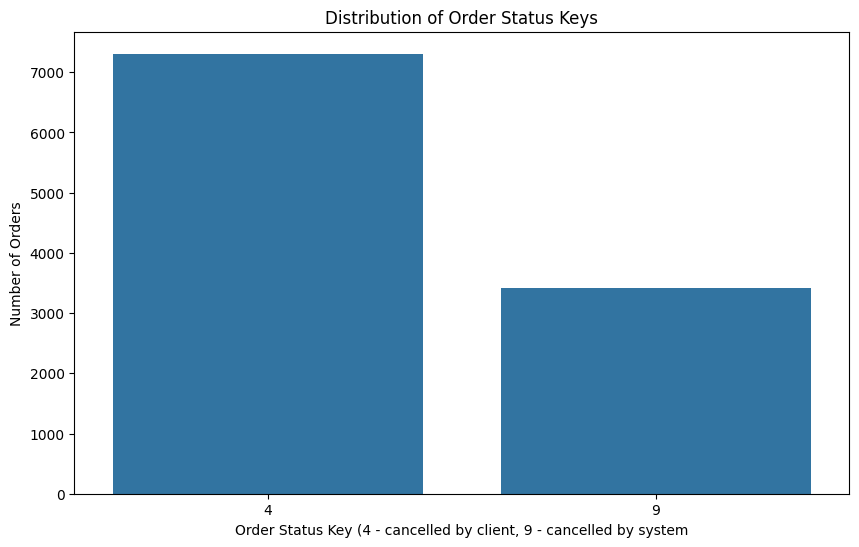

In [31]:
status_counts = df2['order_status_key'].value_counts()
print(status_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=status_counts.index, y=status_counts.values)
plt.title('Distribution of Order Status Keys')
plt.xlabel('Order Status Key (4 - cancelled by client, 9 - cancelled by system')
plt.ylabel('Number of Orders')
plt.show()

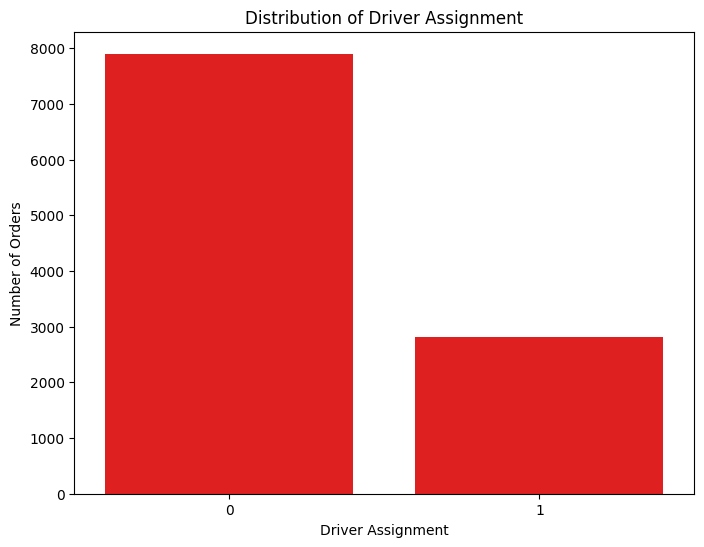

In [11]:
assign_count = df2["is_driver_assigned_key"].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=assign_count.index, y=assign_count.values,color = "red")
plt.title('Distribution of Driver Assignment')
plt.xlabel('Driver Assignment')
plt.ylabel('Number of Orders')
plt.show()

In [12]:
assigned_and_long_cancellation = df2[(df2['is_driver_assigned_key'] == 1) & (df2['cancellations_time_in_seconds'] > 100)]
count_assigned_and_long_cancellation = len(assigned_and_long_cancellation)

print(f"Number of orders where driver was assigned and cancellation time > 100 seconds: {count_assigned_and_long_cancellation}")

not_assigned_drivers = df2[df2['is_driver_assigned_key']==0].count()
print(f'Number of orders where driver was not assigned: {not_assigned_drivers}')


Number of orders where driver was assigned and cancellation time > 100 seconds: 1586
Number of orders where driver was not assigned: order_datetime                   7902
origin_longitude                 7902
origin_latitude                  7902
m_order_eta                      7902
order_gk                         7902
order_status_key                 7902
is_driver_assigned_key           7902
cancellations_time_in_seconds    7902
dtype: int64


In [26]:
# No driver assigned - added column
df2['failure_reason'] = np.where(
    df2['is_driver_assigned_key'] == 0,
    'No Driver Assigned',
    'Driver Cancelled'
)
df2.head(90)

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds,failure_reason,hour
0,2026-06-15 18:08:07,-0.978916,51.456173,60.0,3000583041974,4,1,198.0,Driver Cancelled,18
1,2026-06-15 20:57:32,-0.950385,51.456843,0.0,3000583116437,4,0,128.0,No Driver Assigned,20
2,2026-06-15 12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0,Driver Cancelled,12
3,2026-06-15 13:50:20,-1.054671,51.460544,658.0,3000582941169,4,1,62.0,Driver Cancelled,13
4,2026-06-15 21:24:45,-0.967605,51.458236,0.0,3000583140877,9,0,0.0,No Driver Assigned,21
...,...,...,...,...,...,...,...,...,...,...
85,2026-06-15 22:13:50,-0.956998,51.449458,0.0,3000623143125,4,0,28.0,No Driver Assigned,22
86,2026-06-15 08:26:32,-1.047778,51.446982,0.0,3000622815834,9,0,0.0,No Driver Assigned,8
87,2026-06-15 07:49:59,-0.992317,51.441893,960.0,3000622791841,4,1,114.0,Driver Cancelled,7
88,2026-06-15 15:50:26,-0.966518,51.454786,0.0,3000622991982,4,0,148.0,No Driver Assigned,15


In [25]:
df2['order_datetime'] = pd.to_datetime(df2['order_datetime'])

df2['hour'] = df2['order_datetime'].dt.hour

/tmp/ipykernel_4391/2574106419.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2['order_datetime'] = pd.to_datetime(df2['order_datetime'])


In [28]:
hourly_failures = (
    df2.groupby(['hour', 'failure_reason'])
       .size()
       .reset_index(name='count')
)

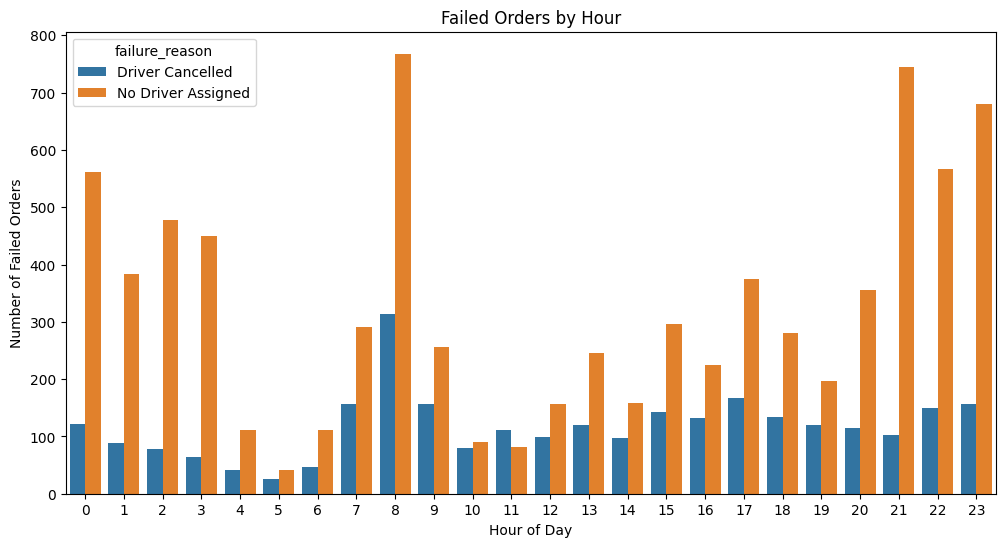

In [29]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=hourly_failures,
    x='hour',
    y='count',
    hue='failure_reason'
)

plt.title('Failed Orders by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Failed Orders')
plt.show()